## Supernova distances and redshifts (part 1):
###  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

#### If you have time (or later at home...)

- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

(35.0, 50.0)

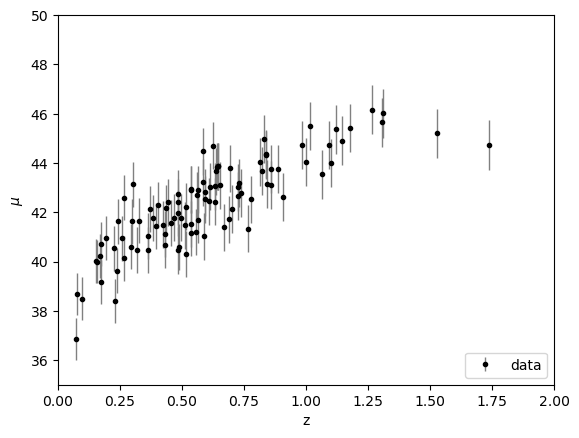

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Linear Regression:

In [65]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(z_sample[:,None], mu_sample[:,None], dmu)
X = np.linspace(0, 2, 100)
y = lin_reg.predict(X[:,None])

(35.0, 50.0)

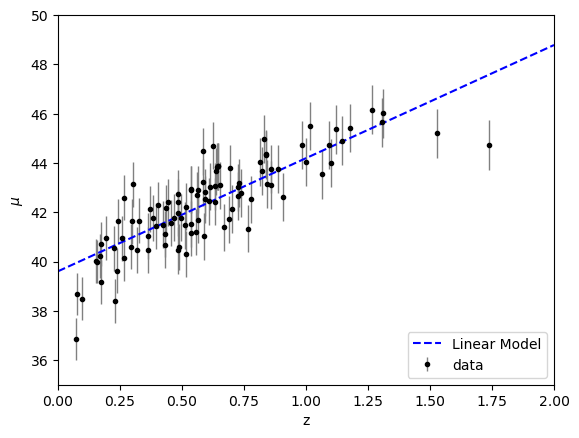

In [66]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X, y, '--b', label = 'Linear Model')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Polynomial Regression: 

(35.0, 50.0)

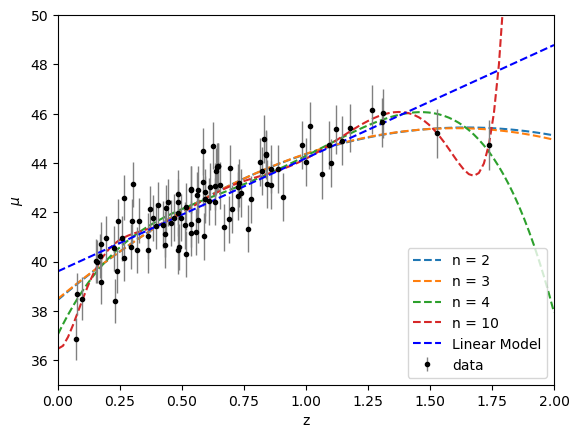

In [67]:
from astroML.linear_model import PolynomialRegression

degrees = np.array([2, 3, 4, 10])

for i in degrees:
    model = PolynomialRegression(i)
    model.fit(z_sample[:,None], mu_sample)
    y_poly = model.predict(X[:,None])
    plt.plot(X, y_poly, '--', label = f'n = {i}')


plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X, y, '--b', label = 'Linear Model')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


Clearly with a 10th degree polynomial fit we are overfitting the data! In particular the last 2 points seem to influence a lot how the function behaves for high z!

The best fit seems to be either n = 2 or 3, but let's see what CV has to say:

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LeaveOneOut

param_grid = {'degree': [2, 3, 4, 5, 10]}

X_train, X_test, y_train, y_test = train_test_split(z_sample, mu_sample, test_size=0.7, train_size=0.3)

cv = LeaveOneOut() #Using LeaveOneOut as we have few points!
gridCV = GridSearchCV(PolynomialRegression(), param_grid, cv = cv, scoring='neg_mean_squared_error')
gridCV.fit(X_train[:, None], y_train)
best_model = gridCV.best_estimator_
print("Best degree:", gridCV.best_params_['degree'])

Best degree: 3


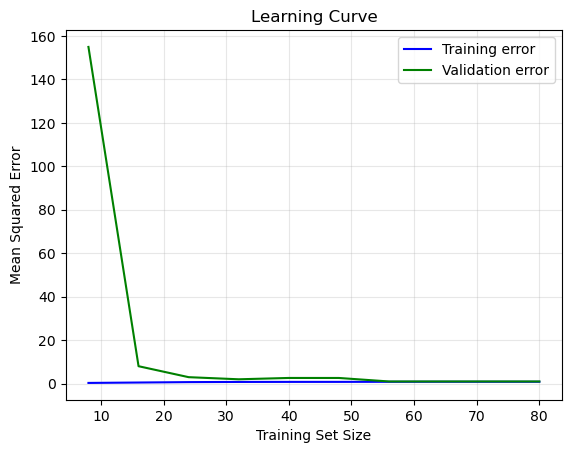

In [69]:
from sklearn.model_selection import learning_curve

train_size_abs, train_scores, test_scores = learning_curve(best_model, z_sample[:,None], mu_sample,
                                                           train_sizes=np.linspace(0.1, 1.0, 10), 
                                                           cv=5, scoring='neg_mean_squared_error',
                                                           shuffle=True)

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.plot(train_size_abs, train_scores_mean, '-', color='blue', label='Training error')
plt.plot(train_size_abs, test_scores_mean, '-', color='green', label='Validation error')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.grid(alpha = 0.3)


In [70]:
#Ok, we have a 70/30 train/test split which is more then we need but it's ok anyway
y_pred = best_model.predict(X_test[:,None])

(35.0, 50.0)

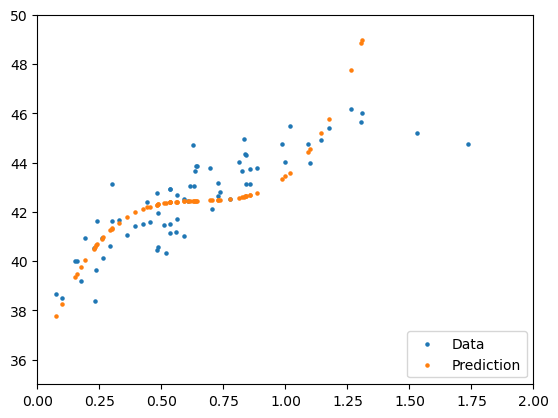

In [71]:
plt.scatter(X_test, y_test, label = 'Data', s = 5)
plt.scatter(X_test, y_pred, label = 'Prediction', s = 5)
plt.legend(loc = 'lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Basis Function Regression:

(35.0, 50.0)

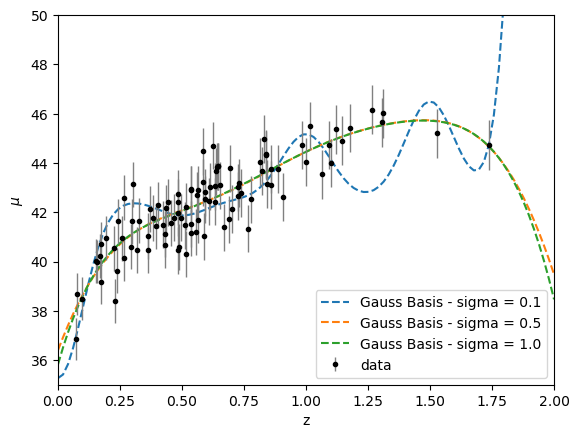

In [72]:
from astroML.linear_model import BasisFunctionRegression

mu_pos = np.linspace(0, 2, 5)[:,None]
sigmas = np.array([0.1, 0.5, 1])

for i in range(len(sigmas)):
    gaussReg = BasisFunctionRegression('gaussian', mu=mu_pos, sigma=sigmas[i])
    gaussReg.fit(z_sample[:,None], mu_sample, dmu)
    y_bas = gaussReg.predict(X[:,None])
    plt.plot(X, y_bas, '--', label = f'Gauss Basis - sigma = {sigmas[i]}')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

###  Kernel Regression:

(35.0, 50.0)

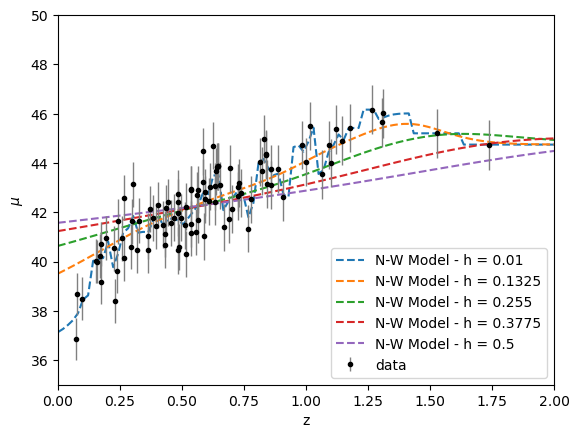

In [73]:
from astroML.linear_model import NadarayaWatson


h = np.linspace(0.01, 0.5, 5)
for i in range(len(h)):
    kerReg = NadarayaWatson('gaussian',h = h[i])
    kerReg.fit(z_sample[:,None], mu_sample)
    y_ker = kerReg.predict(X[:,None])
    plt.plot(X, y_ker, '--', label = f'N-W Model - h = {h[i]}')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Increasing the number of points:

(35.0, 50.0)

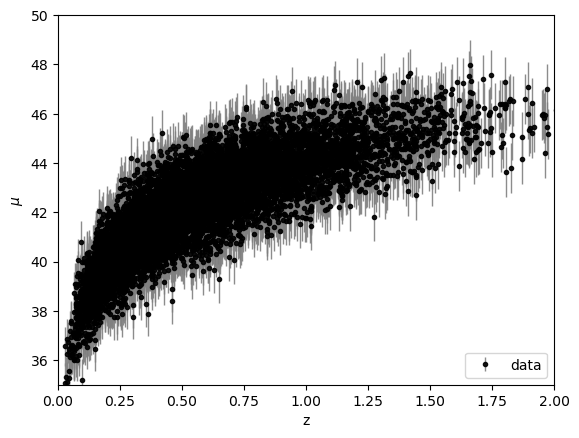

In [74]:
z_new, mu_new, dmu_new = generate_mu_z(10000, random_state=1234)

plt.errorbar(z_new, mu_new, dmu_new, fmt='.k', ecolor='gray', lw=1,label='data', alpha = 0.9)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

#Much more data here !

(35.0, 50.0)

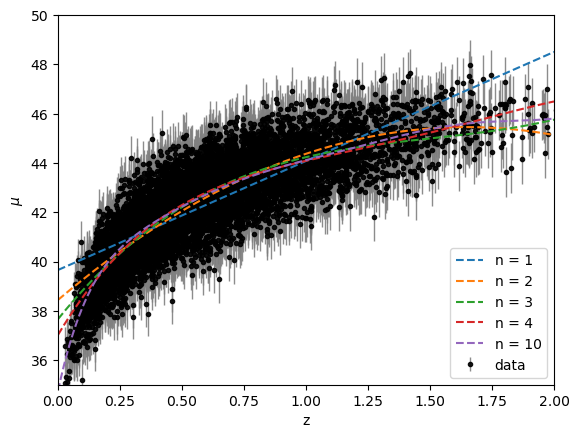

In [75]:
degrees = np.array([1, 2, 3, 4, 10])
X = np.linspace(0, 2, 1000)
for i in degrees:
    model = PolynomialRegression(i)
    model.fit(z_new[:,None], mu_new)
    y_poly_new = model.predict(X[:,None])
    plt.plot(X, y_poly_new, '--', label = f'n = {i}')

plt.errorbar(z_new, mu_new, dmu_new, fmt='.k', ecolor='gray', lw=1,label='data', alpha = 0.9, zorder=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [79]:
param_grid = {'degree': [1, 2, 3, 4, 10, 20]}

X_train, X_test, y_train, y_test = train_test_split(z_new, mu_new, test_size=0.8, train_size=0.2)

cv = 100 #Going back to the k-fold as we have much more data!
gridCV = GridSearchCV(PolynomialRegression(), param_grid, cv = cv, scoring='neg_mean_squared_error')
gridCV.fit(X_train[:, None], y_train)

GridSearchCV(cv=100, estimator=PolynomialRegression(),
             param_grid={'degree': [1, 2, 3, 4, 10, 20]},
             scoring='neg_mean_squared_error')

In [80]:
print("Best degree:", gridCV.best_params_['degree'])
best_model = gridCV.best_estimator_

Best degree: 10


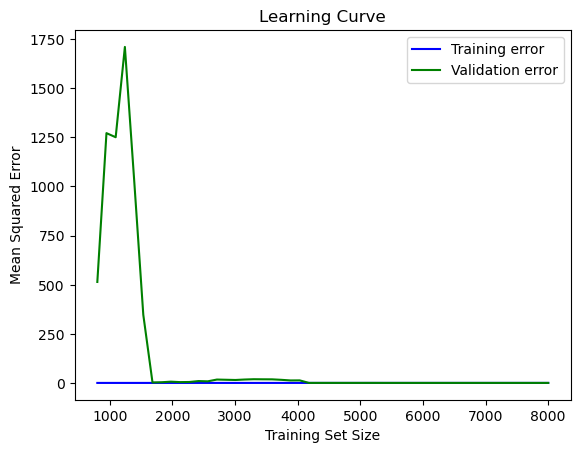

In [81]:
train_size_abs, train_scores, test_scores = learning_curve(best_model, z_new[:,None], mu_new,
                                                           train_sizes=np.linspace(0.1, 1.0, 50), 
                                                           cv=5, scoring='neg_mean_squared_error')

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.plot(train_size_abs, train_scores_mean, '-', color='blue', label='Training error')
plt.plot(train_size_abs, test_scores_mean, '-', color='green', label='Validation error')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()

So a trainig set with 2000 points is enough ! Let's check it out.

In [82]:
X_train, X_test, y_train, y_test = train_test_split(z_new, mu_new, test_size=0.8, train_size=0.2)
best_model.fit(X_train[:,None], y_train)
best_y_pred = best_model.predict(X_test[:,None])

(35.0, 50.0)

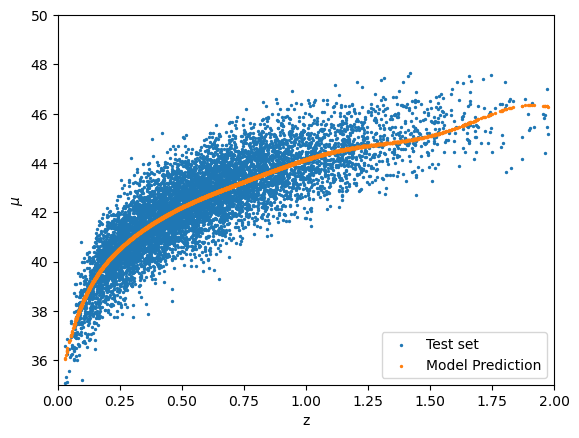

In [83]:
plt.scatter(X_test, y_test, label = 'Test set', s = 2)
plt.scatter(X_test, best_y_pred, label = 'Model Prediction', s = 2)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

Quite a good fit! We just saw that changing the number of data did change our result a lot. We went from a polynomial of 3rd degree to one of 10th degree due to the fact that we have much more data to 'explain' with our model! Nevertheless, even with such a high degree polynomial fit, the covariance error is still low, we do not seem to be overfitting our data, even with a relatively small training set.